# Projeto Prático 2 — Detecção de Baleias via Satélite
### Dataset: Whales from Satellite (Roboflow) | Modelos: YOLO26 Nano e Small


In [ ]:
!pip install -q ultralytics roboflow
import ultralytics
from ultralytics import YOLO
from roboflow import Roboflow
import os
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import shutil
import random
from pathlib import Path


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
SAVE_DIR = ''
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow
API_KEY = "dLoPNRzkupKzHfcqNdJH"
rf = Roboflow(api_key=API_KEY)

project = rf.workspace("yolov8-whale-detection").project("whales-from-satellite")
dataset = project.version(8).download("yolo26")

DATASET_PATH = dataset.location
print(f'Dataset baixado em: {DATASET_PATH}')


loading Roboflow workspace...
loading Roboflow project...
Dataset baixado em: /content/Whales-from-Satellite-8


In [ ]:
splits = ['train', 'valid', 'test']
counts = {}

for split in splits:
    img_path = os.path.join(DATASET_PATH, split, 'images')
    if os.path.exists(img_path):
        n = len([f for f in os.listdir(img_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        counts[split] = n
        print(f'  {split:6s}: {n} imagens')
    else:
        print(f'  {split:6s}: pasta não encontrada')
        counts[split] = 0

total = sum(counts.values())
print(f'\n  Total: {total} imagens')
print(f'\n  Meta:  train=1000 | valid=150 | test=300 | Total=1450')

  train : 3151 imagens
  valid : 895 imagens
  test  : 432 imagens

  Total: 4478 imagens

  Meta:  train=1000 | valid=150 | test=300 | Total=1450


In [ ]:
random.seed(42)

all_images = []
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    if os.path.exists(img_dir):
        for f in os.listdir(img_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images.append(os.path.join(img_dir, f))

print(f'Total de imagens disponíveis: {len(all_images)}')

TOTAL_NEEDED = 1000 + 150 + 300  # = 1450

if len(all_images) < TOTAL_NEEDED:
    print(f'Dataset tem apenas {len(all_images)} imagens (necessário: {TOTAL_NEEDED})')
    print('   Ajustando proporcionalmente ao disponível...')
    ratio = len(all_images) / TOTAL_NEEDED
    N_TRAIN = int(1000 * ratio)
    N_VAL   = int(150  * ratio)
    N_TEST  = int(300  * ratio)
    while N_TRAIN + N_VAL + N_TEST > len(all_images):
        N_TEST -= 1
    print(f'   Novo split: train={N_TRAIN} | valid={N_VAL} | test={N_TEST}')
else:
    N_TRAIN = 1000
    N_VAL   = 150
    N_TEST  = 300
    print(f'Imagens suficientes! Selecionando {TOTAL_NEEDED} de {len(all_images)}')

random.shuffle(all_images)

train_imgs = all_images[:N_TRAIN]
val_imgs   = all_images[N_TRAIN : N_TRAIN + N_VAL]
test_imgs  = all_images[N_TRAIN + N_VAL : N_TRAIN + N_VAL + N_TEST]


NEW_DATASET = '/dataset_balanced'

if os.path.exists(NEW_DATASET):
    shutil.rmtree(NEW_DATASET)

def copy_split(img_list, split_name):
    img_out = os.path.join(NEW_DATASET, split_name, 'images')
    lbl_out = os.path.join(NEW_DATASET, split_name, 'labels')
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    copied = 0
    missing_labels = 0

    for img_path in img_list:
        # Copiar imagem
        img_name = os.path.basename(img_path)
        shutil.copy2(img_path, os.path.join(img_out, img_name))

        stem = Path(img_name).stem
        lbl_src = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

        if os.path.exists(lbl_src):
            shutil.copy2(lbl_src, os.path.join(lbl_out, stem + '.txt'))
        else:
            # Criar label vazio se não existir (imagem sem anotação)
            open(os.path.join(lbl_out, stem + '.txt'), 'w').close()
            missing_labels += 1
        copied += 1

    print(f'  {split_name:6s}: {copied} imagens copiadas | {missing_labels} sem label')
    return copied

print('\nCopiando splits...')
copy_split(train_imgs, 'train')
copy_split(val_imgs,   'valid')
copy_split(test_imgs,  'test')

print(f'\nDataset balanceado criado em: {NEW_DATASET}')

Total de imagens disponíveis: 4478
✅ Imagens suficientes! Selecionando 1450 de 4478

Copiando splits...
  train : 1000 imagens copiadas | 0 sem label
  valid : 150 imagens copiadas | 0 sem label
  test  : 300 imagens copiadas | 0 sem label

✅ Dataset balanceado criado em: /content/dataset_balanced


In [ ]:
original_yaml = os.path.join(DATASET_PATH, 'data.yaml')

with open(original_yaml, 'r') as f:
    orig = yaml.safe_load(f)

print('Classes encontradas no dataset original:')
print(orig.get('names', 'Não encontrado'))

new_yaml = {
    'path': NEW_DATASET,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    orig.get('nc', 1),
    'names': orig.get('names', ['whale'])
}

YAML_PATH = os.path.join(NEW_DATASET, 'data.yaml')
with open(YAML_PATH, 'w') as f:
    yaml.dump(new_yaml, f, default_flow_style=False)

print(f'\ndata.yaml criado em: {YAML_PATH}')
print('\nConteúdo:')
with open(YAML_PATH) as f:
    print(f.read())

Classes encontradas no dataset original:
['whale']

✅ data.yaml criado em: /content/dataset_balanced/data.yaml

Conteúdo:
names:
- whale
nc: 1
path: /content/dataset_balanced
test: test/images
train: train/images
val: valid/images



In [ ]:
print('='*45)
print('   CONFIRMAÇÃO DO DATASET BALANCEADO')
print('='*45)
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(NEW_DATASET, split, 'images')
    lbl_dir = os.path.join(NEW_DATASET, split, 'labels')
    n_imgs  = len(os.listdir(img_dir))
    n_lbls  = len(os.listdir(lbl_dir))
    print(f'  {split:6s}: {n_imgs} imagens | {n_lbls} labels')

print('='*45)
print('  Meta: train=1000 | valid=150 | test=300')
print('='*45)

   CONFIRMAÇÃO DO DATASET BALANCEADO
  train : 1000 imagens | 1000 labels
  valid : 150 imagens | 150 labels
  test  : 300 imagens | 300 labels
  Meta: train=1000 | valid=150 | test=300


In [ ]:
from ultralytics import YOLO
import torch

# Carregar modelo YOLO26 nano com pesos pré-treinados (COCO)
model_nano = YOLO('yolo26n.pt')

# Treinar com os hiperparâmetros obrigatórios
results_nano = model_nano.train(
    data    = YAML_PATH,
    epochs  = 100,
    lr0     = 0.001,
    patience= 20,
    freeze  = 10,
    imgsz   = 640,
    batch   = 16,        # Reduzir para 8 se der OOM
    device  = 0 if torch.cuda.is_available() else 'cpu',
    project = '/content/resultados',
    name    = 'yolo26n_whales',
    exist_ok= True,
    plots   = True,
    verbose = True
)

print(f'   Pesos salvos em: /content/resultados/yolo26n_whales/weights/best.pt')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_whales, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [ ]:
model_small = YOLO('yolo26s.pt')

# Treinar com os hiperparâmetros obrigatórios
results_small = model_small.train(
    data    = YAML_PATH,
    epochs  = 100,
    lr0     = 0.001,
    patience= 20,
    freeze  = 10,
    imgsz   = 640,
    batch   = 16,
    device  = 0 ,
    project = '/content/resultados',
    name    = 'yolo26s_whales',
    exist_ok= True,
    plots   = True,
    verbose = True
)

print(f'   Pesos salvos em: /content/resultados/yolo26s_whales/weights/best.pt')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_whales, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [ ]:
model_nano_best = YOLO('/content/resultados/yolo26n_whales/weights/best.pt')

metrics_nano = model_nano_best.val(
    data  = YAML_PATH,
    split = 'test',
    imgsz = 640,
    plots = True,
    verbose = True
)

print('\n📈 Métricas YOLO26 Nano (Test Set):')
print(f'   mAP@50:     {metrics_nano.box.map50:.4f}')
print(f'   mAP@50-95:  {metrics_nano.box.map:.4f}')
print(f'   Precision:  {metrics_nano.box.mp:.4f}')
print(f'   Recall:     {metrics_nano.box.mr:.4f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2.2±1.8 MB/s, size: 3.6 KB)
val: Scanning /content/dataset_balanced/test/labels... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 1.2Kit/s 0.3s
val: New cache created: /content/dataset_balanced/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 371, len(boxes) = 373. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.5it/s 5.4s
                   all        300        373      0.775      0.788      0.788       0.34
Speed: 3.7ms preprocess, 5.6ms inference, 0.0ms loss, 0.4ms postpro

In [ ]:
model_small_best = YOLO('/content/resultados/yolo26s_whales/weights/best.pt')

metrics_small = model_small_best.val(
    data  = YAML_PATH,
    split = 'test',
    imgsz = 640,
    plots = True,
    verbose = True
)

print('\n📈 Métricas YOLO26 Small (Test Set):')
print(f'   mAP@50:     {metrics_small.box.map50:.4f}')
print(f'   mAP@50-95:  {metrics_small.box.map:.4f}')
print(f'   Precision:  {metrics_small.box.mp:.4f}')
print(f'   Recall:     {metrics_small.box.mr:.4f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 204.5±102.6 MB/s, size: 2.8 KB)
val: Scanning /content/dataset_balanced/test/labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 104.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 371, len(boxes) = 373. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.5it/s 5.4s
                   all        300        373       0.79      0.776      0.785      0.356
Speed: 2.7ms preprocess, 10.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/v

          COMPARAÇÃO — YOLO26 Nano vs Small
Métrica                  YOLO26 Nano    YOLO26 Small
------------------------------------------------------------
mAP@50                        0.7876          0.7855
mAP@50-95                     0.3401          0.3555
Precision                     0.7748          0.7898
Recall                        0.7882          0.7758


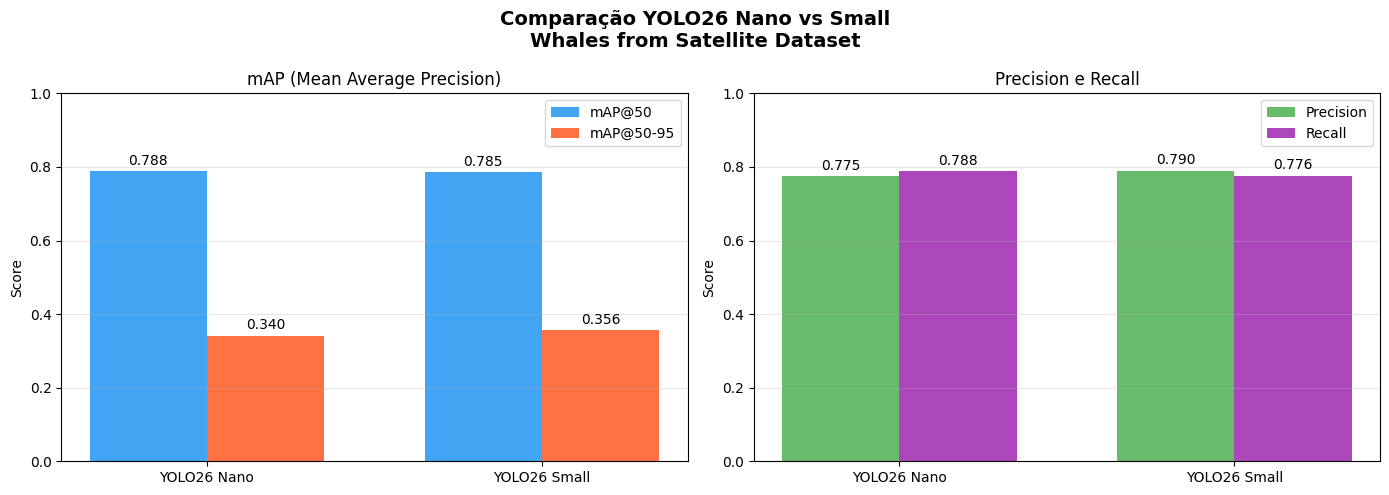

✅ Gráfico salvo em /content/comparacao_nano_vs_small.png


In [ ]:
# ── Dados coletados ──
modelos   = ['YOLO26 Nano', 'YOLO26 Small']
map50     = [metrics_nano.box.map50,  metrics_small.box.map50]
map5095   = [metrics_nano.box.map,    metrics_small.box.map]
precision = [metrics_nano.box.mp,     metrics_small.box.mp]
recall    = [metrics_nano.box.mr,     metrics_small.box.mr]

# ── Tabela resumo ──
print('='*60)
print('          COMPARAÇÃO — YOLO26 Nano vs Small')
print('='*60)
print(f"{'Métrica':<20} {'YOLO26 Nano':>15} {'YOLO26 Small':>15}")
print('-'*60)
print(f"{'mAP@50':<20} {map50[0]:>15.4f} {map50[1]:>15.4f}")
print(f"{'mAP@50-95':<20} {map5095[0]:>15.4f} {map5095[1]:>15.4f}")
print(f"{'Precision':<20} {precision[0]:>15.4f} {precision[1]:>15.4f}")
print(f"{'Recall':<20} {recall[0]:>15.4f} {recall[1]:>15.4f}")
print('='*60)

# ── Gráfico de barras comparativo ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação YOLO26 Nano vs Small\nWhales from Satellite Dataset', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#FF5722']
x = np.arange(len(modelos))
width = 0.35

# mAP@50 e mAP@50-95
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, map50,   width, label='mAP@50',    color=colors[0], alpha=0.85)
bars2 = ax1.bar(x + width/2, map5095, width, label='mAP@50-95', color=colors[1], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos)
ax1.set_ylim(0, 1)
ax1.set_title('mAP (Mean Average Precision)')
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

# Precision e Recall
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, precision, width, label='Precision', color='#4CAF50', alpha=0.85)
bars4 = ax2.bar(x + width/2, recall,    width, label='Recall',    color='#9C27B0', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(modelos)
ax2.set_ylim(0, 1)
ax2.set_title('Precision e Recall')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/content/comparacao_nano_vs_small.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo em /content/comparacao_nano_vs_small.png')

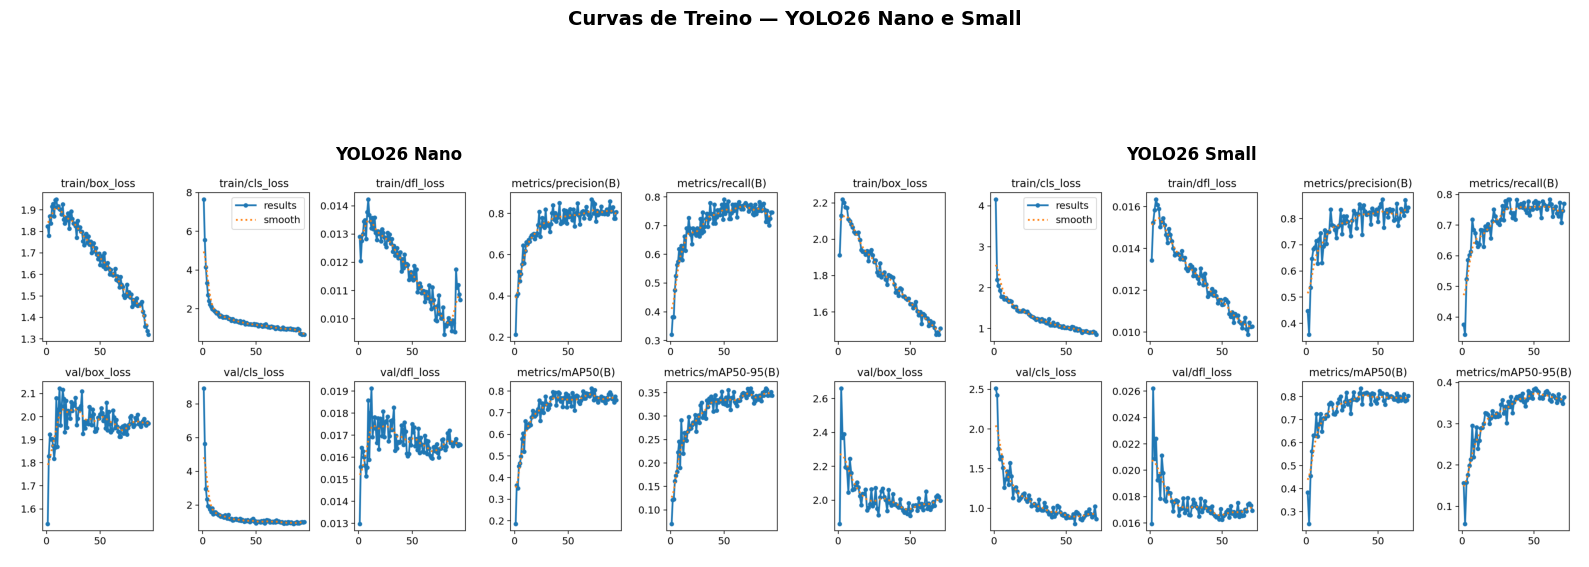

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Curvas de Treino — YOLO26 Nano e Small', fontsize=14, fontweight='bold')

plots = [
    ('/content/resultados/yolo26n_whales/results.png', 'YOLO26 Nano'),
    ('/content/resultados/yolo26s_whales/results.png', 'YOLO26 Small'),
]

for ax, (plot_path, title) in zip(axes, plots):
    if os.path.exists(plot_path):
        img = mpimg.imread(plot_path)
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, f'Arquivo não encontrado:\n{plot_path}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.savefig('/content/curvas_treino.png', dpi=150, bbox_inches='tight')
plt.show()


0: 640x640 1 whale, 9.4ms
1: 640x640 2 whales, 9.4ms
2: 640x640 (no detections), 9.4ms
3: 640x640 2 whales, 9.4ms
4: 640x640 1 whale, 9.4ms
5: 640x640 1 whale, 9.4ms
Speed: 2.0ms preprocess, 9.4ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/predicoes/nano_test


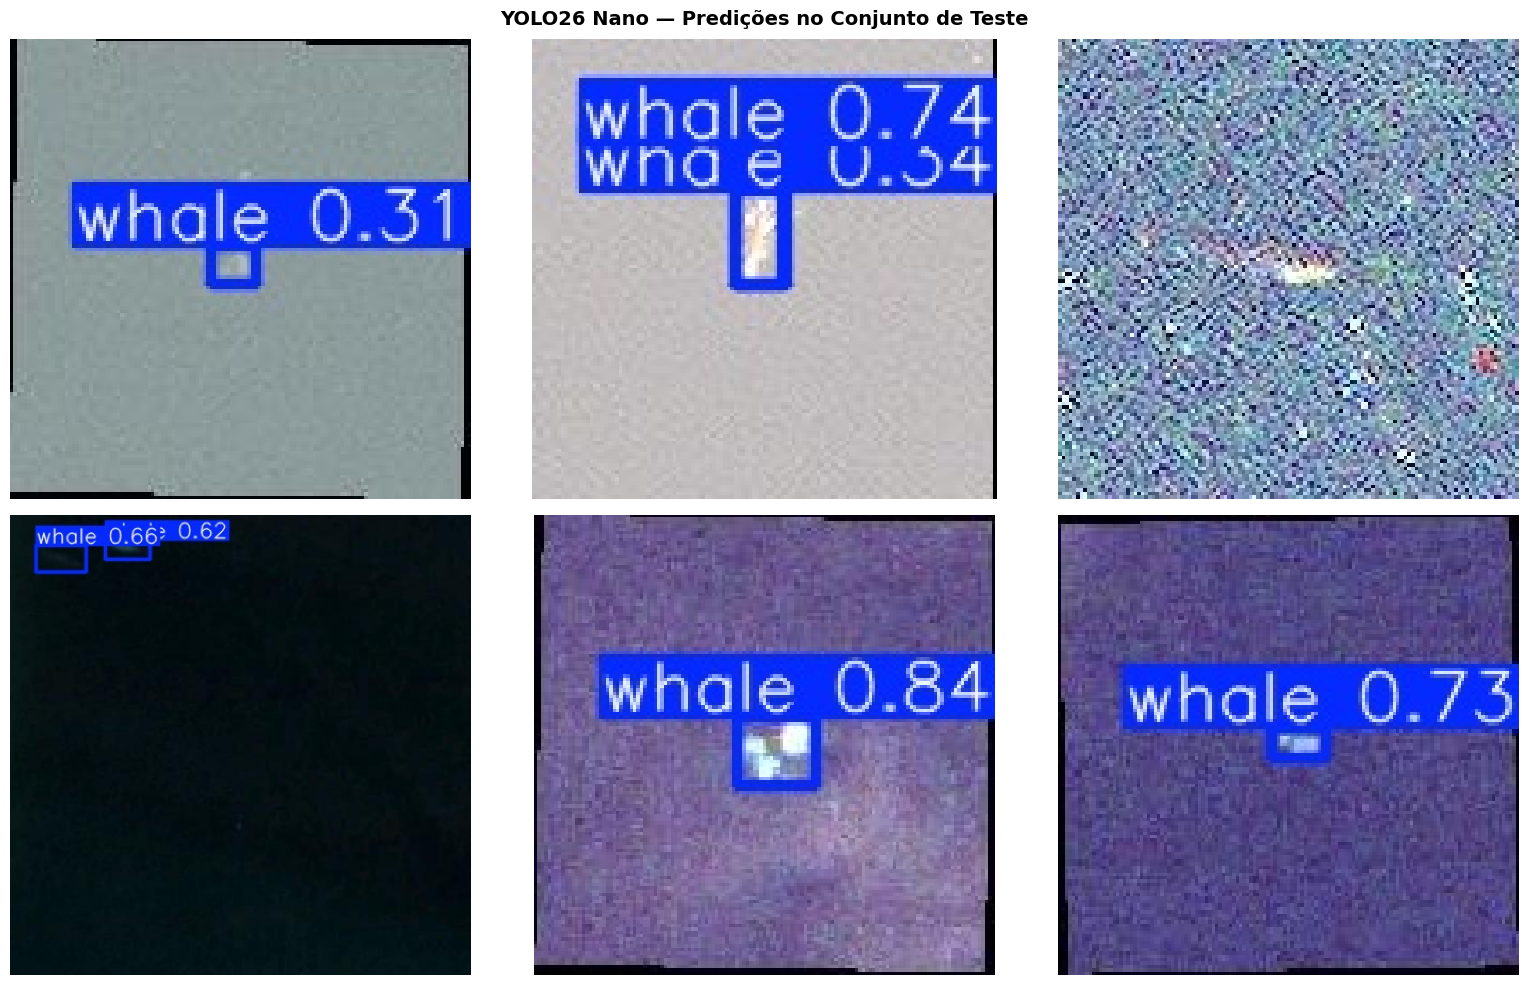

✅ Predições salvas em /content/predicoes_nano.png


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

model_nano_best = YOLO('/content/resultados/yolo26n_whales/weights/best.pt')

# Pegar 6 imagens aleatórias do conjunto de teste
test_images_dir = os.path.join(NEW_DATASET, 'test', 'images')
test_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
sample_files = random.sample(test_files, min(6, len(test_files)))
sample_paths = [os.path.join(test_images_dir, f) for f in sample_files]

# Rodar inferência
results = model_nano_best.predict(
    source  = sample_paths,
    imgsz   = 640,
    conf    = 0.25,
    save    = True,
    project = '/content/predicoes',
    name    = 'nano_test',
    exist_ok= True
)

# Mostrar resultado
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('YOLO26 Nano — Predições no Conjunto de Teste', fontsize=14, fontweight='bold')

pred_dir = '/content/predicoes/nano_test'
pred_files = sorted(os.listdir(pred_dir))[:6]

for ax, fname in zip(axes.flat, pred_files):
    img = mpimg.imread(os.path.join(pred_dir, fname))
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/predicoes_nano.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Predições salvas em /content/predicoes_nano.png')

In [ ]:
import shutil
import os

SAVE_DIR = '/content/drive/MyDrive/PP2_Whales_YOLO26'
os.makedirs(SAVE_DIR, exist_ok=True)

# Arquivos a salvar
to_copy = [
    ('/content/resultados/yolo26n_whales/weights/best.pt',   f'{SAVE_DIR}/yolo26n_best.pt'),
    ('/content/resultados/yolo26s_whales/weights/best.pt',   f'{SAVE_DIR}/yolo26s_best.pt'),
    ('/content/resultados/yolo26n_whales/results.png',        f'{SAVE_DIR}/yolo26n_results.png'),
    ('/content/resultados/yolo26s_whales/results.png',        f'{SAVE_DIR}/yolo26s_results.png'),
    ('/content/comparacao_nano_vs_small.png',                  f'{SAVE_DIR}/comparacao_nano_vs_small.png'),
    ('/content/curvas_treino.png',                             f'{SAVE_DIR}/curvas_treino.png'),
    ('/content/predicoes_nano.png',                            f'{SAVE_DIR}/predicoes_nano.png'),
]

print('Salvando arquivos no Google Drive...')
for src, dst in to_copy:
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f'  ✅ {os.path.basename(dst)}')
    else:
        print(f'  ⚠️ Não encontrado: {src}')

# Copiar pasta de resultados completa
for model_name in ['yolo26n_whales', 'yolo26s_whales']:
    src_dir = f'/content/resultados/{model_name}'
    dst_dir = f'{SAVE_DIR}/{model_name}'
    if os.path.exists(src_dir):
        if os.path.exists(dst_dir):
            shutil.rmtree(dst_dir)
        shutil.copytree(src_dir, dst_dir)
        print(f'  ✅ Pasta completa: {model_name}')

print(f'\n✅ Tudo salvo em: {SAVE_DIR}')

Salvando arquivos no Google Drive...
  ✅ yolo26n_best.pt
  ✅ yolo26s_best.pt
  ✅ yolo26n_results.png
  ✅ yolo26s_results.png
  ✅ comparacao_nano_vs_small.png
  ✅ curvas_treino.png
  ✅ predicoes_nano.png
  ✅ Pasta completa: yolo26n_whales
  ✅ Pasta completa: yolo26s_whales

✅ Tudo salvo em: /content/drive/MyDrive/PP2_Whales_YOLO26


In [ ]:
print('='*65)
print('   RESUMO FINAL — PROJETO PRÁTICO 2')
print('   Dataset: Whales from Satellite (Roboflow)')
print('='*65)
print(f'\n  📁 Split utilizado:')
print(f'      Treino:    {N_TRAIN} imagens')
print(f'      Validação: {N_VAL}   imagens')
print(f'      Teste:     {N_TEST}  imagens')
print(f'\n  ⚙️  Hiperparâmetros:')
print(f'      Épocas:    100')
print(f'      lr0:       0.001')
print(f'      patience:  20')
print(f'      freeze:    10')
print(f'      imgsz:     640')
print(f'\n  🤖 Resultados no conjunto de TESTE:')
print(f'  {"Modelo":<14} {"mAP@50":>8} {"mAP@50-95":>10} {"Precision":>10} {"Recall":>8}')
print(f'  {"-"*55}')
print(f'  {"YOLO26 Nano":<14} {metrics_nano.box.map50:>8.4f} {metrics_nano.box.map:>10.4f} {metrics_nano.box.mp:>10.4f} {metrics_nano.box.mr:>8.4f}')
print(f'  {"YOLO26 Small":<14} {metrics_small.box.map50:>8.4f} {metrics_small.box.map:>10.4f} {metrics_small.box.mp:>10.4f} {metrics_small.box.mr:>8.4f}')
print('='*65)
print(f'\n  🗓️  Defesa: 11/06')
print(f'  💾  Resultados salvos no Google Drive: PP2_Whales_YOLO26/')
print('='*65)

   RESUMO FINAL — PROJETO PRÁTICO 2
   Dataset: Whales from Satellite (Roboflow)

  📁 Split utilizado:
      Treino:    1000 imagens
      Validação: 150   imagens
      Teste:     300  imagens

  ⚙️  Hiperparâmetros:
      Épocas:    100
      lr0:       0.001
      patience:  20
      freeze:    10
      imgsz:     640

  🤖 Resultados no conjunto de TESTE:
  Modelo           mAP@50  mAP@50-95  Precision   Recall
  -------------------------------------------------------
  YOLO26 Nano      0.7876     0.3401     0.7748   0.7882
  YOLO26 Small     0.7855     0.3555     0.7898   0.7758

  🗓️  Defesa: 11/06
  💾  Resultados salvos no Google Drive: PP2_Whales_YOLO26/
